# Probando DarkELF

In [ ]:
import sys
from pathlib import Path

import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt
import pandas as pd

# Point Python at the local DarkELF package.
darkelf_root = Path("/home/lurishi/DarkELF")
sys.path.append(str(darkelf_root))
alpha_em = 1 / 137.035999084
from darkelf import darkelf
#%matplotlib qt

custom_params = {
    'font.family': 'serif',
}

plt.rcParams.update(custom_params)
# Pick the target material whose dielectric response you want to use.
# Ge and Si are the default tabulated materials in DarkELF.
target = "Si"
material = darkelf(
    target=target,
    filename=f"{target}_gpaw_withLFE.dat",
    phonon_filename=f"{target}_epsphonon_data2K.dat",
)


 .... Loading files for Si
Loaded Si_gpaw_withLFE.dat for epsilon in electron regime
electronic ELF taken or calculated from J. Enkovaara et al.,Electronic structure calculations with GPAW: a real-space implementation of the projector augmented-wave method,Journal of Physics:Condensed Matter22(2010) 253202.
Warning! eps for phonon frequencies not loaded. Need to set phonon_filename to perform data-driven, single phonon calculations
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, “Intensity of diffracted intensities,” in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554–595, https://onlinelibrary.wiley.com/doi/pdf/10.1107/97809553602060000
Loaded /home/lurishi/DarkELF/darkelf/../data/Si/Si_pDoS.dat for part

In [2]:
# This evaluates the integrand in the displayed formula:
#   1/k * Im[-1/epsilon(omega, k)]
#   + k * (beta^2 - omega^2/k^2) * Im[1/(-k^2 + epsilon(omega, k) * omega^2)]
# DarkELF provides epsilon1/epsilon2 and elf; the second term is built directly here.
def mcp_integrand(k, omega, beta, material, method="grid"):
    eps1 = material.eps1(omega, k, method=method)   # omega [eV], k [keV] — convención DarkELF
    eps2 = material.eps2(omega, k, method=method)
    epsilon = eps1 + 1j * eps2

    omega_keV = omega / 1000.0   # <-- clave: pasar omega a keV para que combine con k

    with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
        longitudinal = material.elf(omega, k, method=method) / k

        omega_over_k = omega_keV / k
        k2 = k * k
        beta2 = beta * beta
        denom = -k2 + epsilon * omega_keV**2
        transverse = k * (beta2 - omega_over_k**2) * np.imag(1.0 / denom)

    total = longitudinal + transverse
    if not np.isfinite(total):
        return 0.0
    return total


def mcp_integral_scipy(omega, beta, material, method="grid", kmin=1e-6, kmax=None):
    if kmax is None:
        kmax = material.kmax

    value, error = integrate.quad(
        lambda k: mcp_integrand(k, omega, beta, material, method=method),
        kmin,
        kmax,
        limit=200,
    )
    return value, error

In [3]:
def mcp_integral(omega, beta, material, method="grid", kmin=1e-6, kmax=None, npts=1000, k_scale=None):

    k_values = np.logspace(np.log10(omega/beta), 3, npts)
    integrand_values = np.array([
        mcp_integrand(k, omega, beta, material, method=method)
        for k in k_values
    ])

    value = np.trapezoid(integrand_values, k_values)
    return value

In [4]:
beta = 1
omega_values = np.linspace(5, 50, 1000)
dsigma_dE = np.zeros_like(omega_values)

for i, omega in enumerate(omega_values):
    value = mcp_integral(omega, beta, material, method="grid", kmax=None, npts=400)
    #value,error= mcp_integral_scipy(omega, beta, material, kmin=1e-6, kmax=None)
    dsigma_dE[i] = value

In [5]:
dsigma_dE

array([ 0.45438342,  0.43956682,  0.42560358,  0.4339539 ,  0.4419726 ,
        0.4494541 ,  0.45613508,  0.46171043,  0.46587328,  0.43866254,
        0.39692522,  0.36455819,  0.33869591,  0.31752762,  0.29985233,
        0.28484164,  0.29738227,  0.31252256,  0.32275203,  0.32524898,
        0.31778736,  0.29990053,  0.27341043,  0.28420353,  0.29604374,
        0.3088586 ,  0.32275918,  0.33786955,  0.35432542,  0.37218388,
        0.37755084,  0.38284957,  0.38804265,  0.39308628,  0.39792874,
        0.40251746,  0.40679084,  0.41331236,  0.41975397,  0.42550868,
        0.43029885,  0.43376703,  0.43546977,  0.43485662,  0.44439964,
        0.46403945,  0.48548137,  0.50896401,  0.53476481,  0.56320983,
        0.59468282,  0.62629846,  0.63822096,  0.65074745,  0.66393602,
        0.67785277,  0.69257221,  0.70817814,  0.72476902,  0.7479034 ,
        0.77660421,  0.80569839,  0.8350836 ,  0.86463352,  0.89419577,
        0.92359027,  0.9526086 ,  0.95262543,  0.94258562,  0.93

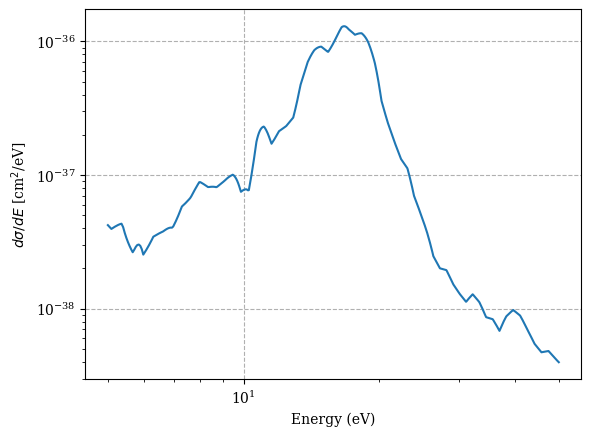

In [6]:
alpha_em = 1 / 137.035999084
n = 5e22          # densidad atómica de Si [cm^-3] — consistente con la normalización de Essig et al.
eps_charge = 1e-6  # <-- el valor real de la Fig. 1

dsigma_dE_scaled = dsigma_dE * (2*alpha_em*eps_charge**2) / (n*np.pi*beta**2)

plt.plot(omega_values, dsigma_dE_scaled)
plt.xlabel("Energy (eV)")
plt.ylabel(r"$d\sigma/dE$ [cm$^2$/eV]")
plt.yscale("log")
plt.xscale("log")
plt.grid(linestyle="--")

In [7]:
import pandas as pd
df = pd.read_csv("/home/lurishi/Escritorio/Doctorado/Mcp_gráficos_papers/Darkelfmcp.csv",sep=";")


In [8]:
df.dtypes

Er           float64
dsigma_de    float64
dtype: object

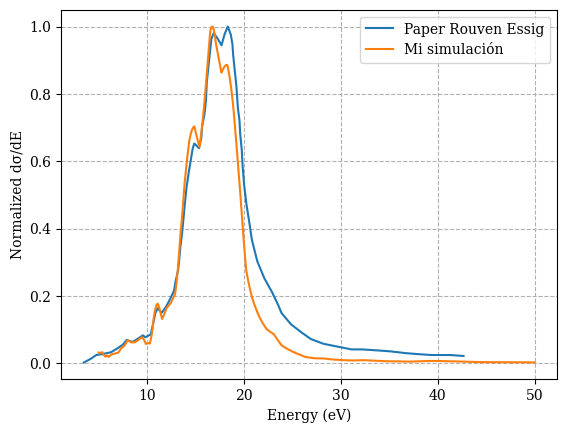

In [9]:
plt.plot(df[df.columns[0]], df[df.columns[1]]/df[df.columns[1]].max())
plt.plot(omega_values, dsigma_dE_scaled/dsigma_dE_scaled.max())
plt.xlabel("Energy (eV)")
plt.ylabel("Normalized dσ/dE")
plt.legend([f"Paper Rouven Essig", "Mi simulación"])
plt.grid(linestyle="--")


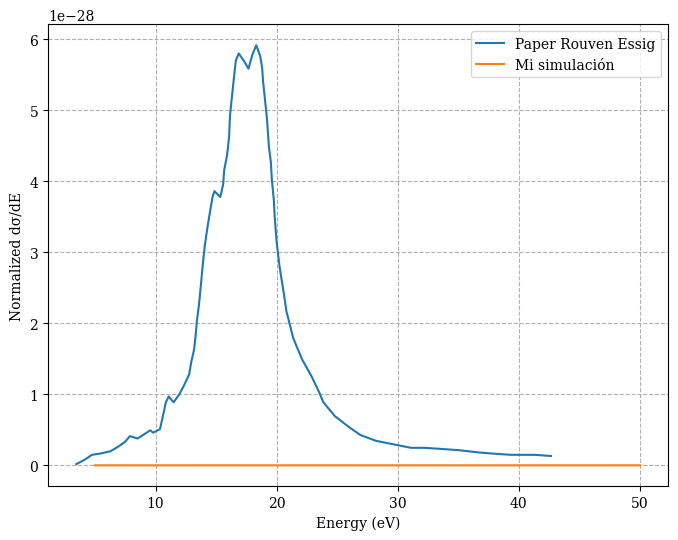

In [10]:
plt.close('all')
factor = 4.6*1e4
plt.figure(figsize=(8,6))
plt.plot(df[df.columns[0]], df[df.columns[1]])
plt.plot(omega_values, dsigma_dE_scaled*factor)
plt.xlabel("Energy (eV)")
plt.ylabel("Normalized dσ/dE")
plt.legend([f"Paper Rouven Essig", "Mi simulación"])
plt.grid(linestyle="--")

In [ ]:
import sys
from pathlib import Path
import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt

darkelf_root = Path("/home/lurishi/DarkELF")
sys.path.append(str(darkelf_root))
from darkelf import darkelf

alpha_em = 1 / 137.035999084

target = "Si"
material = darkelf(
    target=target,
    filename=f"{target}_gpaw_withLFE.dat",     # <- DarkELF (GPAW), como en la Fig. 3
    phonon_filename=f"{target}_epsphonon_data2K.dat",
)

def mcp_integrand(k, omega, beta, material, method="grid"):
    """
    k     : momentum transfer [keV]  (convención DarkELF)
    omega : energy transfer   [eV]   (convención DarkELF)
    Devuelve el integrando de la Ec. (1) de Essig et al., d(algo)/dk,
    con omega convertido a keV internamente para que combine con k.
    """
    eps1 = material.eps1(omega, k, method=method)
    eps2 = material.eps2(omega, k, method=method)
    epsilon = eps1 + 1j * eps2

    omega_keV = omega    # <- fix: mismas unidades que k

    with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
        longitudinal = material.elf(omega, k, method=method) / k

        omega_over_k = omega_keV / k
        k2 = k * k
        beta2 = beta * beta
        denom = -k2 + epsilon * omega_keV**2
        transverse = k * (beta2 - omega_over_k**2) * np.imag(1.0 / denom)

    total = longitudinal + transverse
    if not np.isfinite(total):
        return 0.0
    return total


def mcp_integral(omega, beta, material, method="grid", npts=1000):
    kmin = omega / beta    # eV -> keV, mínimo momentum transfer físico
    kmax = material.kmax           # cutoff numérico de la tabla de DarkELF
    k_values = np.logspace(np.log10(kmin), np.log10(kmax), npts)
    integrand_values = np.array([
        mcp_integrand(k, omega, beta, material, method=method)
        for k in k_values
    ])
    return np.trapezoid(integrand_values, k_values)


# --- Parámetros de la Fig. 3 (panel a) ---
beta = 1.0
eps_charge = 1e-4
n_Si = 4.99e22   # cm^-3, densidad atómica de Si

omega_values = np.linspace(10, 50, 100)   # eV; evito omega=0 exacto
dsigma_domega = np.array([
    mcp_integral(omega, beta, material, npts=400) for omega in omega_values
])

prefactor = 2 * alpha_em * eps_charge**2 / (n_Si * np.pi * beta**2)
dsigma_domega_scaled = dsigma_domega * prefactor   # cm^2 eV^-1 atom^-1



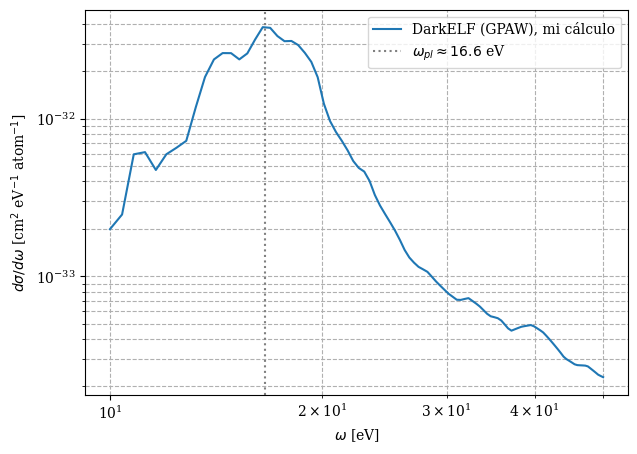

In [18]:
plt.figure(figsize=(7,5))
plt.plot(omega_values, dsigma_domega_scaled, label="DarkELF (GPAW), mi cálculo")
plt.xlabel(r"$\omega$ [eV]")
plt.ylabel(r"$d\sigma/d\omega$ [cm$^2$ eV$^{-1}$ atom$^{-1}$]")
plt.axvline(16.6, color="gray", ls=":", label=r"$\omega_{pl}\approx16.6$ eV")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid(linestyle="--",which="both")
plt.show()